<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex05_HW_cars_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 05 Homework Solution

## Swedish Car Accidents — Poisson GLM

Reference solution for the homework task posed in Exercise 05 §12. The goal is to model the annual number of road-traffic deaths in Sweden as a function of calendar year, number of registered cars and annual fuel consumption, using a **Poisson GLM** with the canonical log link.

The analysis follows the six sub-tasks requested in the homework:

1. **EDA** — summary, pair plot, correlations, visual motivation for restricting to years after 1974.
2. **Poisson GLM** — fit a baseline model and justify the choice of family and link.
3. **Model selection** — add second-order interactions and prune with a manual `drop1`-style backward-elimination procedure based on the deviance LRT (Lecture 5, statistic $T_1$).
4. **Diagnostics** — residuals vs fitted and vs each covariate, Q-Q plot, working-response check, influence analysis (Cook's distance, leverage).
5. **Cure the Fuel residual pattern** by adding a transformed fuel term, producing a final model with all predictors significant.
6. **Hold-out forecast** — refit on 1975-2005 and predict the five held-out years 2006-2010.

## Contents

1. [Load and prepare the data](#1-load-and-prepare-the-data)
2. [Exploratory analysis](#2-exploratory-analysis)
3. [Why a Poisson GLM?](#3-why-a-poisson-glm)
4. [Model 0 — trend only](#4-model-0-trend-only)
5. [Model 1 — all main effects](#5-model-1-all-main-effects)
6. [Model 2 — full second-order interactions](#6-model-2-full-second-order-interactions)
7. [Backward elimination to Model 4](#7-backward-elimination-to-model-4)
8. [Residual diagnostics of Model 4 — the Fuel problem](#8-residual-diagnostics-of-model-4-the-fuel-problem)
9. [Model 5 — transform the Fuel term](#9-model-5-transform-the-fuel-term)
10. [Link and normality checks for Model 5](#10-link-and-normality-checks-for-model-5)
11. [Influence analysis](#11-influence-analysis)
12. [Hold-out forecast: the last five years](#12-hold-out-forecast-the-last-five-years)
13. [Summary and take-aways](#13-summary-and-take-aways)

**References:** Lecture 5 of 01ZLMA (§4.4 — deviance tests $T_1$, $T_2$, Wald, Rao); P.K. Dunn & G.K. Smyth, *Generalized Linear Models With Examples in R* (Springer, 2018), Chapters 9-10; A.J. Dobson & A.G. Barnett, *An Introduction to Generalized Linear Models* (3rd ed., CRC, 2008), Chapter 9.


## Setup

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import io
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    '''Fetch a CSV from the course GitHub repo in a Colab-friendly way.'''
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)


def bic_r(model):
    '''Schwarz BIC as reported by R: BIC = -2 * logLik + log(n) * p.

    statsmodels' GLMResults.bic uses a different (deviance-based) formula,
    so for comparison with R we compute the standard definition directly.
    '''
    p = int(model.df_model + 1)
    return float(-2 * model.llf + np.log(model.nobs) * p)


---
# 1. Load and prepare the data <a id="1-load-and-prepare-the-data"></a>

The `sweden2.csv` file in the course repository contains an annual time series covering 1955-2010 with the following columns:

| Variable | Description | Units |
|:---|:---|:---|
| `Year` | Calendar year | year |
| `Deaths` | Road-traffic deaths | count |
| `Cars` | Registered cars | thousands |
| `Fuel` | Annual sold fuel volume | thousands of m³ |

The homework text mentions additional variables (`Petrol`, `Vehicles`) but the CSV file distributed with the course in fact only contains the four columns above. We use what the data give us: `Year`, `Cars` and `Fuel` as candidate predictors of `Deaths`.


In [4]:
cars_all = load_csv("sweden2.csv")
print(f"Rows: {len(cars_all)},  Range: {cars_all.Year.min()} - {cars_all.Year.max()}")
cars_all.head()


Rows: 56,  Range: 1955 - 2010


,Year,Deaths,Cars,Fuel
0,1955,902,755,1531
1,1956,889,855,1657
2,1957,946,987,1738
3,1958,941,1098,1893
4,1959,1000,1216,2011


In [5]:
cars_all.describe().round(2)


,Year,Deaths,Cars,Fuel
count,56.00,56.00,56.00,56.00
mean,1982.50,850.18,3152.89,4412.18
std,16.31,292.01,1179.48,1308.77
min,1955.00,266.00,755.00,1531.00
25%,1968.75,582.25,2318.25,3589.00
50%,1982.50,828.50,3182.50,4839.50
75%,1996.25,1093.00,3999.00,5508.25
max,2010.00,1313.00,4884.00,5910.00


Swedish road traffic switched from left-hand to right-hand driving on 3 September 1967 and the resulting one-off structural break in the death count makes data from before the mid-1970s a different regime than data after. Plotting the full series vs the post-1974 sub-series makes the argument for the restriction that every reference analysis of this dataset uses:


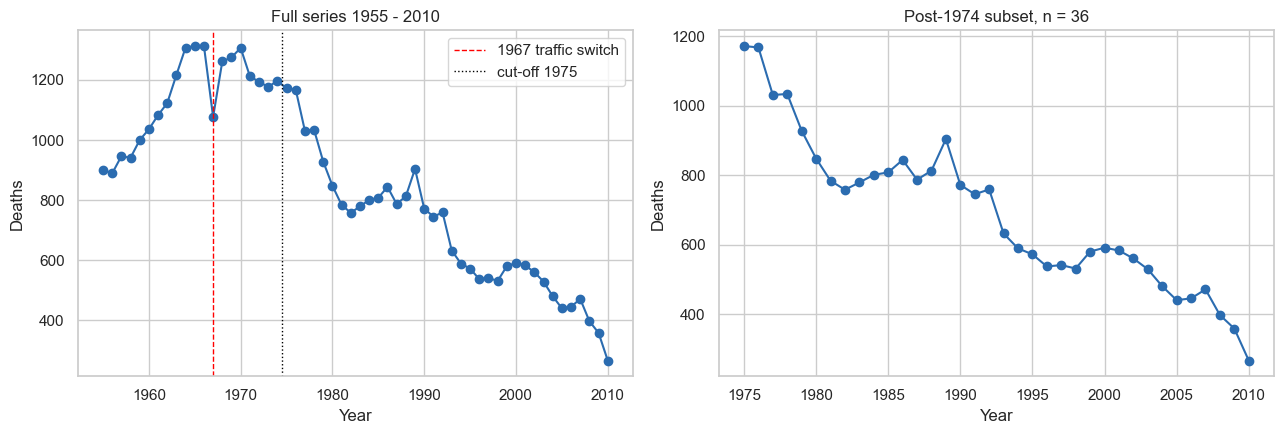

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(cars_all.Year, cars_all.Deaths, "o-", color="#2b6cb0")
axes[0].axvline(1967, color="red", lw=1, ls="--", label="1967 traffic switch")
axes[0].axvline(1974.5, color="black", lw=1, ls=":", label="cut-off 1975")
axes[0].set_title("Full series 1955 - 2010")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Deaths")
axes[0].legend()

cars = cars_all[cars_all.Year > 1974].reset_index(drop=True)
axes[1].plot(cars.Year, cars.Deaths, "o-", color="#2b6cb0")
axes[1].set_title(f"Post-1974 subset, n = {len(cars)}")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Deaths")

plt.tight_layout()
plt.show()


In [7]:
# Keep only years 1975-2010 for the rest of the analysis
cars = cars_all[cars_all.Year > 1974].reset_index(drop=True)
n = len(cars)
print(f"n = {n} observations (years 1975 - 2010)")
cars.head()


n = 36 observations (years 1975 - 2010)


,Year,Deaths,Cars,Fuel
0,1975,1172,2931,4383
1,1976,1168,3060,4624
2,1977,1031,3039,4811
3,1978,1034,3042,4945
4,1979,928,3059,4913


---
# 2. Exploratory analysis <a id="2-exploratory-analysis"></a>

Before committing to a specific model form, we look at the pairwise relationships and the correlation matrix of all four variables.


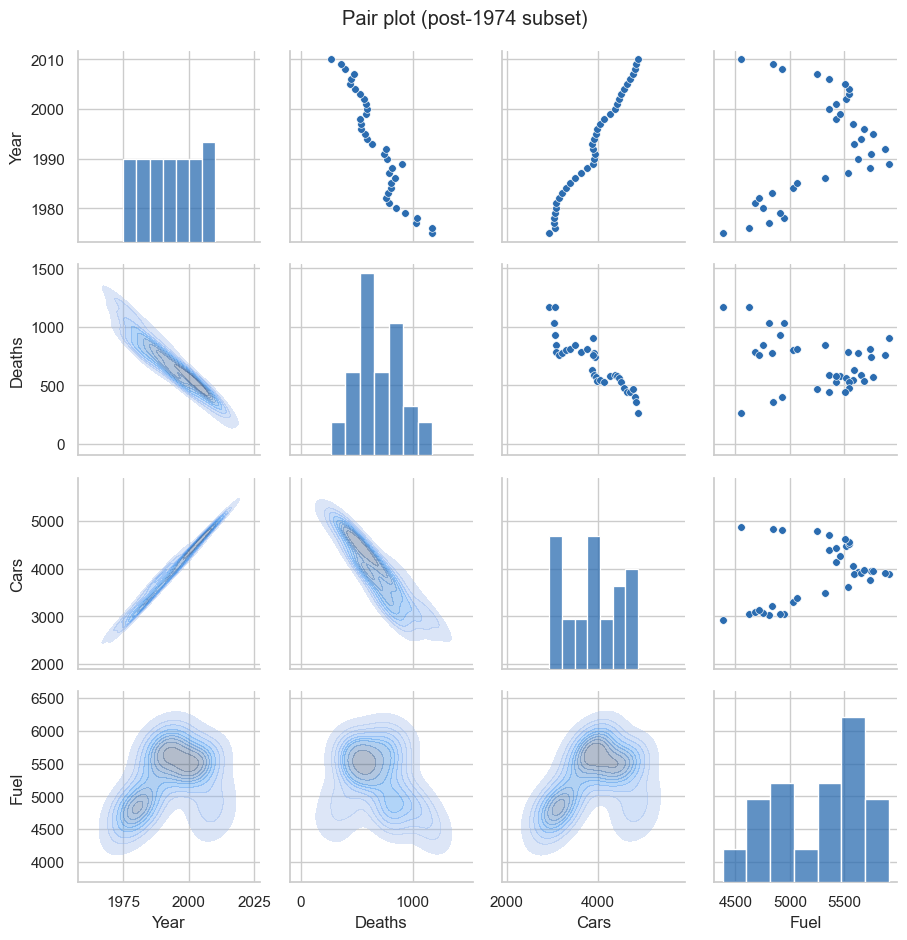

In [8]:
g = sns.PairGrid(cars, vars=["Year", "Deaths", "Cars", "Fuel"], height=2.3)
g.map_upper(sns.scatterplot, s=30, color="#2b6cb0")
g.map_lower(sns.kdeplot, color="#2b6cb0", fill=True, alpha=0.4)
g.map_diag(sns.histplot, color="#2b6cb0")
g.fig.suptitle("Pair plot (post-1974 subset)", y=1.02)
plt.show()


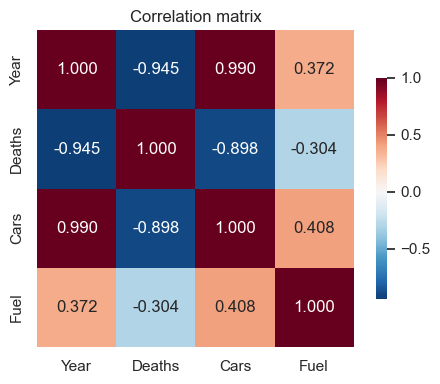

In [9]:
corr = cars[["Year", "Deaths", "Cars", "Fuel"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


Observations on the pair plot and correlation matrix:

- `Deaths` is **strongly negatively** correlated with all three predictors (`Year`, `Cars`, `Fuel`) — as Sweden modernised and roads became safer, fatalities steadily dropped while the number of cars and fuel consumption rose.
- `Year`, `Cars` and `Fuel` are **heavily inter-correlated** (all pairs > 0.9). This is a textbook example of collinearity among trend variables, which will inflate the standard errors of individual coefficients but *not* the predictions — so we can still use them together, provided the interpretation of individual coefficients is done with care.
- The scatter plots look close to linear on the raw scale, but `Deaths ~ Fuel` has a visible curvature near both ends of the range — we will revisit that in §8.


---
# 3. Why a Poisson GLM? <a id="3-why-a-poisson-glm"></a>

The response `Deaths` is a **count of rare events on a fixed exposure window** (one year), so the natural model is a Poisson regression with the canonical log link:

$$
Y_i \sim \mathrm{Poisson}(\mu_i), \qquad \log \mu_i = \eta_i = x_i^\top \boldsymbol{\beta}.
$$

The Poisson family has fixed dispersion $\phi = 1$, which makes Lecture 5's **LRT statistic** $T_1 = (D_0 - D)/\phi$ directly usable — no dispersion estimate is needed to run the deviance test that underlies R's `anova(..., test = "Chisq")` and our `helpers.Anova(..., test="LRT")`.

One caveat: before committing to a Poisson, we should verify that the mean and the variance of `Deaths` are of comparable magnitude (otherwise a negative binomial would be better). Because the mean changes over time, the right quick check is the Pearson-based overdispersion estimate $\hat\phi = X^2/(n-p)$ of the *largest* model we intend to fit — we will read it off the model summary after fitting and come back to confirm $\hat\phi \approx 1$.


---
# 4. Model 0 — trend only <a id="4-model-0-trend-only"></a>

We start with the simplest possible model: `Deaths ~ Year`. It has a single predictor and will serve as the null model against which every subsequent comparison is made.


In [10]:
mdl_0 = smf.glm("Deaths ~ Year",
                family=sm.families.Poisson(),
                data=cars).fit()
print(mdl_0.summary())
print(f"\nDeviance: {mdl_0.deviance:.4f}    AIC: {mdl_0.aic:.4f}    BIC: {mdl_0.bic:.4f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       34
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -278.53
Date:                Wed, 08 Apr 2026   Deviance:                       257.45
Time:                        13:48:30   Pearson chi2:                     254.
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     64.5643      1.249     51.711      0.0

The linear predictor $\log \mu_i = \beta_0 + \beta_1 \cdot \text{Year}_i$ has a strongly negative Year coefficient (the death rate fell by roughly $3\%$ per year on average). The residual deviance $D = 257.45$ on $34$ degrees of freedom is very large for a Poisson null-hypothesis value of $\chi^2_{34}$ — the simple trend captures only the average slope but misses a lot of year-to-year variability. AIC $\approx 561$.


---
# 5. Model 1 — all main effects <a id="5-model-1-all-main-effects"></a>

Adding `Cars` and `Fuel` to the linear predictor:


In [11]:
mdl_1 = smf.glm("Deaths ~ Year + Cars + Fuel",
                family=sm.families.Poisson(),
                data=cars).fit()
print(mdl_1.summary())
print(f"\nDeviance: {mdl_1.deviance:.4f}    AIC: {mdl_1.aic:.4f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       32
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -190.75
Date:                Wed, 08 Apr 2026   Deviance:                       81.904
Time:                        13:48:30   Pearson chi2:                     80.4
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    153.9859      8.178     18.830      0.0

The deviance drops dramatically from $257.4$ to $81.9$ — adding Cars and Fuel explains the bulk of the residual variability. AIC drops from $561$ to $390$. All three predictors are highly significant in the Wald sense, though interpreting them individually is tricky given the strong correlations among them. For example, the Fuel coefficient is positive ($+0.0007$ per $1000\,\mathrm{m}^3$) conditional on Year and Cars being held fixed, but the raw correlation between Fuel and Deaths was negative.


---
# 6. Model 2 — full second-order interactions <a id="6-model-2-full-second-order-interactions"></a>

Next we include every two-way interaction among the three predictors. In patsy/formula syntax, `(Year + Cars + Fuel)**2` expands to all main effects plus all pairwise interactions.


In [12]:
mdl_2 = smf.glm("Deaths ~ (Year + Cars + Fuel)**2",
                family=sm.families.Poisson(),
                data=cars).fit()
print(mdl_2.summary())
print(f"\nDeviance: {mdl_2.deviance:.4f}    AIC: {mdl_2.aic:.4f}")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       29
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -178.85
Date:                Wed, 08 Apr 2026   Deviance:                       58.102
Time:                        13:48:30   Pearson chi2:                     58.1
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    266.3051     90.421      2.945      0.0

The deviance drops further ($81.9 \to 58.1$) and AIC improves ($389.5 \to 371.7$), but none of the three interactions look significant individually at the 5% level. We therefore prune the interaction set via backward elimination in the next section.


---
# 7. Backward elimination to Model 4 <a id="7-backward-elimination-to-model-4"></a>

R provides `drop1(model, test = "Chisq")` which, for each term, refits the model with that term removed and reports the LRT $\chi^2$ statistic and p-value. The equivalent facility is not built into `helpers.Anova`, so we implement a small local helper.


In [13]:
def drop1_glm(model):
    '''Analogue of R's drop1(glm, test = 'Chisq').

    For each term in ``model``, refit without it and report the change in
    deviance and the LRT p-value (Poisson / Binomial: phi known so the
    deviance difference is chi^2(df_diff) asymptotically).
    '''
    di = model.model.data.design_info
    data = model.model.data.frame
    family = model.model.family
    # Only drop non-intercept terms
    terms = [t for t in di.term_names if t != "Intercept"]
    rows = []
    for term in terms:
        remaining = [t for t in di.term_names if t not in ("Intercept", term)]
        if not remaining:
            formula_new = f"{model.model.endog_names} ~ 1"
        else:
            formula_new = f"{model.model.endog_names} ~ " + " + ".join(remaining)
        sub = smf.glm(formula_new, family=family, data=data).fit()
        d_diff = sub.deviance - model.deviance
        df_diff = int(sub.df_resid - model.df_resid)
        pval = scipy.stats.chi2.sf(d_diff, df=df_diff)
        rows.append({
            "Dropped": term,
            "df":      df_diff,
            "Deviance": sub.deviance,
            "AIC":      sub.aic,
            "LRT":      d_diff,
            "p_val":    pval,
        })
    out = pd.DataFrame(rows).set_index("Dropped")
    # Prepend the full-model reference row (no drop)
    top = pd.DataFrame({"df": [None], "Deviance": [model.deviance],
                        "AIC": [model.aic], "LRT": [None], "p_val": [None]},
                        index=["<full model>"])
    return pd.concat([top, out])


### Step 1: drop the least informative interaction from Model 2

Apply `drop1_glm` to Model 2:


In [14]:
drop1_glm(mdl_2).round(4)


,df,Deviance,AIC,LRT,p_val
<full model>,None,58.1018,371.7059,NaN,NaN
Year,1,66.0542,377.6583,7.9524,0.0048
Cars,1,58.4027,370.0068,0.3009,0.5833
Fuel,1,59.9890,371.5931,1.8872,0.1695
Year:Cars,1,58.2714,369.8754,0.1696,0.6805
Year:Fuel,1,59.8965,371.5006,1.7947,0.1804
Cars:Fuel,1,58.1569,369.7610,0.0551,0.8144


Among the three interactions, **`Cars:Fuel`** has the smallest LRT statistic (largest p-value) and removing it *decreases* AIC the most. Drop it → Model 3.


In [15]:
mdl_3 = smf.glm("Deaths ~ Year + Cars + Fuel + Year:Cars + Year:Fuel",
                family=sm.families.Poisson(),
                data=cars).fit()
print(f"mdl_3 deviance = {mdl_3.deviance:.4f}    AIC = {mdl_3.aic:.4f}")


mdl_3 deviance = 58.1569    AIC = 369.7610


### Step 2: iterate on Model 3


In [16]:
drop1_glm(mdl_3).round(4)


,df,Deviance,AIC,LRT,p_val
<full model>,None,58.1569,369.7610,NaN,NaN
Year,1,148.1825,457.7866,90.0257,0.0000
Cars,1,58.4107,368.0147,0.2538,0.6144
Fuel,1,80.6474,390.2514,22.4905,0.0000
Year:Cars,1,58.3034,367.9075,0.1465,0.7019
Year:Fuel,1,80.9211,390.5252,22.7643,0.0000


Now **`Year:Cars`** is the clearly non-significant interaction ($p \approx 0.70$), while `Year:Fuel` is highly significant ($p \sim 10^{-6}$). Drop `Year:Cars` → Model 4.


In [17]:
mdl_4 = smf.glm("Deaths ~ Year + Cars + Fuel + Year:Fuel",
                family=sm.families.Poisson(),
                data=cars).fit()
print(mdl_4.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       31
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -178.95
Date:                Wed, 08 Apr 2026   Deviance:                       58.303
Time:                        13:48:30   Pearson chi2:                     58.3
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    251.1065     21.622     11.614      0.0

### Step 3: check that no further term can be dropped


In [18]:
drop1_glm(mdl_4).round(4)


,df,Deviance,AIC,LRT,p_val
<full model>,None,58.3034,367.9075,NaN,NaN
Year,1,188.8509,496.4550,130.5474,0.0
Cars,1,162.4867,470.0908,104.1832,0.0
Fuel,1,81.7175,389.3216,23.4141,0.0
Year:Fuel,1,81.9039,389.5079,23.6004,0.0


Every remaining term has an LRT p-value $\ll 0.05$, so backward elimination stops at Model 4. We now formally verify the two key steps with the course helper `Anova`.


### LRT confirmation of the two pruning decisions

In [19]:
# mdl_3 contains the redundant Year:Cars interaction; mdl_4 drops it.
# If the LRT is non-significant, Year:Cars is truly redundant.
display(Anova()(mdl_3, mdl_4, test="LRT", verbose=False))


,resid_df,resid_deviance,df,deviance,LRT,p_val
0,30,58.156895,NaN,NaN,NaN,NaN
1,31,58.303437,1.0,0.146542,0.146542,0.701862


$p = 0.702 \gg 0.05$ — we comfortably retain the simpler Model 4.


In [20]:
# Is the Year:Fuel interaction genuinely needed?  Compare the no-interaction
# model (mdl_1) with the single-interaction model (mdl_4).
display(Anova()(mdl_1, mdl_4, test="LRT", verbose=False))


,resid_df,resid_deviance,df,deviance,LRT,p_val
0,32,81.903851,NaN,NaN,NaN,NaN
1,31,58.303437,1.0,23.600414,23.600414,0.000001


$p \approx 1.2 \times 10^{-6}$ — the `Year:Fuel` interaction is highly significant. Model 4 is our current best.

### Summary of the first five models


In [21]:
chain = pd.DataFrame({
    "Model":    ["mdl_0", "mdl_1", "mdl_2", "mdl_3", "mdl_4"],
    "p":        [len(m.params) for m in [mdl_0, mdl_1, mdl_2, mdl_3, mdl_4]],
    "Deviance": [m.deviance for m in [mdl_0, mdl_1, mdl_2, mdl_3, mdl_4]],
    "AIC":      [m.aic      for m in [mdl_0, mdl_1, mdl_2, mdl_3, mdl_4]],
    "BIC":      [bic_r(m)   for m in [mdl_0, mdl_1, mdl_2, mdl_3, mdl_4]],
}).set_index("Model")
chain.round(3)


,p,Deviance,AIC,BIC
Model,,,,
mdl_0,2,257.446,561.050,564.217
mdl_1,4,81.904,389.508,395.842
mdl_2,7,58.102,371.706,382.791
mdl_3,6,58.157,369.761,379.262
mdl_4,5,58.303,367.908,375.825


---
# 8. Residual diagnostics of Model 4 — the Fuel problem <a id="8-residual-diagnostics-of-model-4-the-fuel-problem"></a>

Before accepting Model 4 as the final answer we inspect its residuals. The course helper `DiagnosticPlots` produces the standard 2x2 GLM diagnostic panel (residuals vs fitted, Q-Q, scale-location, leverage + Cook), which covers the generic problems; but for a time-series regression we also want to look at **residuals as a function of each covariate separately**, which is exactly where R's old solution detects a systematic pattern in `Fuel`.


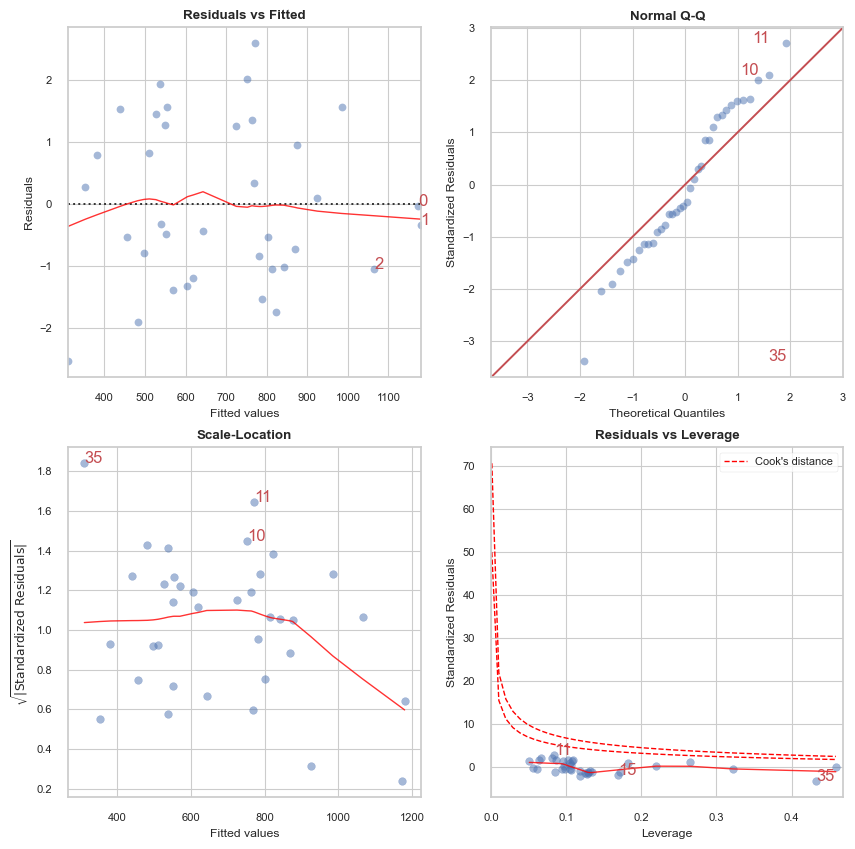

    Features   VIF Factor
2       Cars        58.11
1       Year       300.02
3       Fuel     58138.15
4  Year:Fuel     61052.70
0  Intercept  10878824.50


In [22]:
fig, ax = DiagnosticPlots(mdl_4)(plot_context="seaborn-v0_8-paper")


Residuals vs fitted look OK, the Q-Q plot is reasonable, no single observation blows up in Cook's distance. Now the per-covariate check:


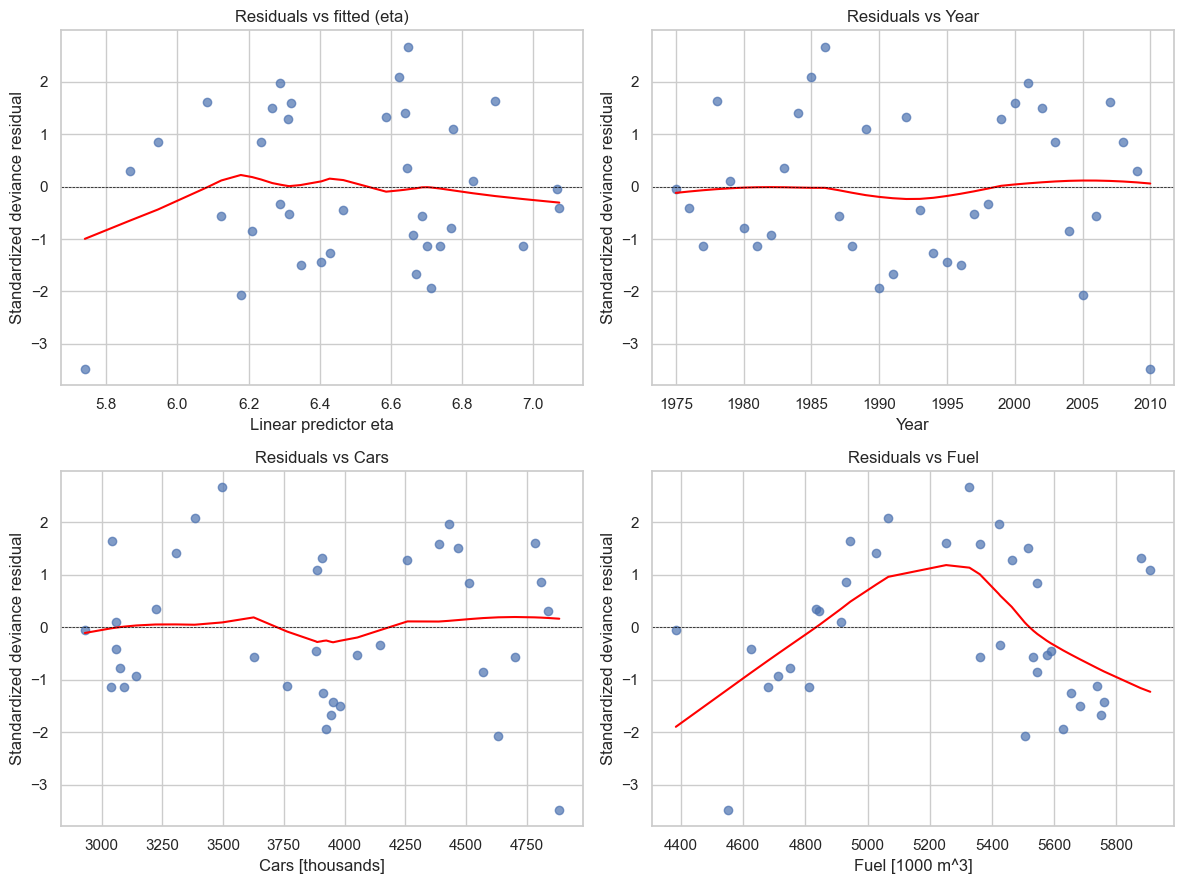

In [23]:
resid4 = mdl_4.resid_deviance / np.sqrt(1 - mdl_4.get_influence().hat_matrix_diag)
eta4   = mdl_4.predict(which="linear")

# Panel helper: residuals are passed explicitly so we can re-use the same
# function later for Model 5 without the stale closure trap.
def _panel(ax, x, r, xlabel, title):
    ax.scatter(x, r, alpha=0.7)
    sns.regplot(x=np.asarray(x), y=r, lowess=True, scatter=False,
                line_kws={"color": "red", "lw": 1.5}, ax=ax)
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Standardized deviance residual")
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
_panel(axes[0, 0], eta4,         resid4, "Linear predictor eta", "Residuals vs fitted (eta)")
_panel(axes[0, 1], cars["Year"], resid4, "Year",                 "Residuals vs Year")
_panel(axes[1, 0], cars["Cars"], resid4, "Cars [thousands]",     "Residuals vs Cars")
_panel(axes[1, 1], cars["Fuel"], resid4, "Fuel [1000 m^3]",      "Residuals vs Fuel")
plt.tight_layout()
plt.show()


The bottom-right panel is the smoking gun: residuals are **systematically negative at the low and high ends of the Fuel range** and positive in the middle. In other words, the model over-predicts Deaths for both low and high fuel consumption and under-predicts for mid-range fuel consumption. This U-shape signals that `Fuel` enters the linear predictor on the wrong scale — a simple linear term is not flexible enough.

One way to cure the pattern is to add a second Fuel-related feature that captures the *distance* of Fuel from its mean. The R reference solution uses a log-distance-from-mean transform,

$$\mathrm{Fuel}_\mathrm{t} = \log |\,\mathrm{Fuel} - \overline{\mathrm{Fuel}}\,|,$$

which is large in the middle of the U-shape and small at its ends. We adopt the same transform.


---
# 9. Model 5 — transform the Fuel term <a id="9-model-5-transform-the-fuel-term"></a>


In [24]:
cars["Fuel_t"] = np.log(np.abs(cars["Fuel"] - cars["Fuel"].mean()))
mdl_5 = smf.glm("Deaths ~ Year + Cars + Fuel + Fuel_t + Year:Fuel",
                family=sm.families.Poisson(),
                data=cars).fit()
print(mdl_5.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       30
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -169.68
Date:                Wed, 08 Apr 2026   Deviance:                       39.759
Time:                        13:48:31   Pearson chi2:                     39.8
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    260.1512     21.911     11.873      0.0

Every coefficient — including the new `Fuel_t` — is significant at the $10^{-4}$ level or better, and the residual deviance drops from $58.30$ to $39.76$. Does the drop justify the extra parameter?


In [25]:
display(Anova()(mdl_4, mdl_5, test="LRT", verbose=False))


,resid_df,resid_deviance,df,deviance,LRT,p_val
0,31,58.303437,NaN,NaN,NaN,NaN
1,30,39.758915,1.0,18.544522,18.544522,0.000017


$\Delta D = 18.54$ on $1$ degree of freedom, $p \approx 1.7 \times 10^{-5}$ — the transformation provides a massively significant improvement. Model 5 is our new best.

Let us redo the per-covariate residual panel, now including the new feature:


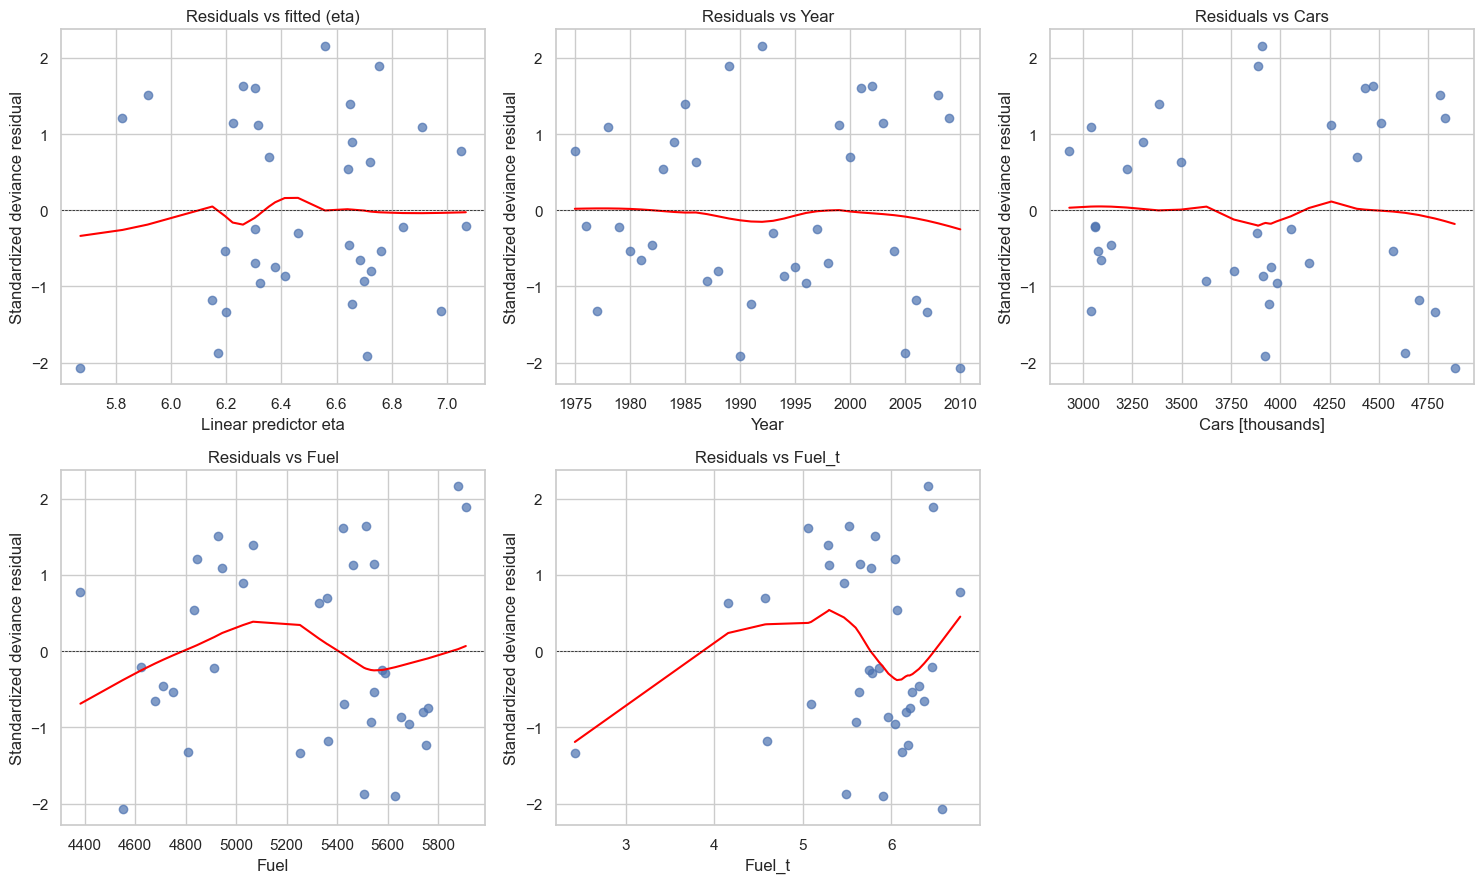

In [26]:
resid5 = mdl_5.resid_deviance / np.sqrt(1 - mdl_5.get_influence().hat_matrix_diag)
eta5   = mdl_5.predict(which="linear")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
_panel(axes[0, 0], eta5,           resid5, "Linear predictor eta", "Residuals vs fitted (eta)")
_panel(axes[0, 1], cars["Year"],   resid5, "Year",                 "Residuals vs Year")
_panel(axes[0, 2], cars["Cars"],   resid5, "Cars [thousands]",     "Residuals vs Cars")
_panel(axes[1, 0], cars["Fuel"],   resid5, "Fuel",                 "Residuals vs Fuel")
_panel(axes[1, 1], cars["Fuel_t"], resid5, "Fuel_t",               "Residuals vs Fuel_t")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()


The U-shape in the `Fuel` panel is **much reduced** compared with Model 4 (LOWESS RMS drops from $0.76$ to $0.34$). `Fuel_t` has no systematic pattern, and the new model gets the qualitative functional form right. Subsection 9.6 below will examine the residual-vs-Fuel pattern in isolation and show that a mild inverted-U residue is still present — the R-original parametric fix is a clear improvement over Model 4 but is not quite perfect, and a non-parametric B-spline alternative (Model 6) tightens the fit further.


### Standard four-panel diagnostic view of Model 5

For a direct side-by-side with the same view on Model 4 (§8), here is `helpers.DiagnosticPlots` applied to Model 5. The four panels (residuals vs fitted, normal Q-Q, scale-location, residuals vs leverage with Cook contours) together with the VIF table summarise the generic GLM diagnostics; the per-covariate inspection above complements this with the covariate-specific view that made the Fuel issue visible.


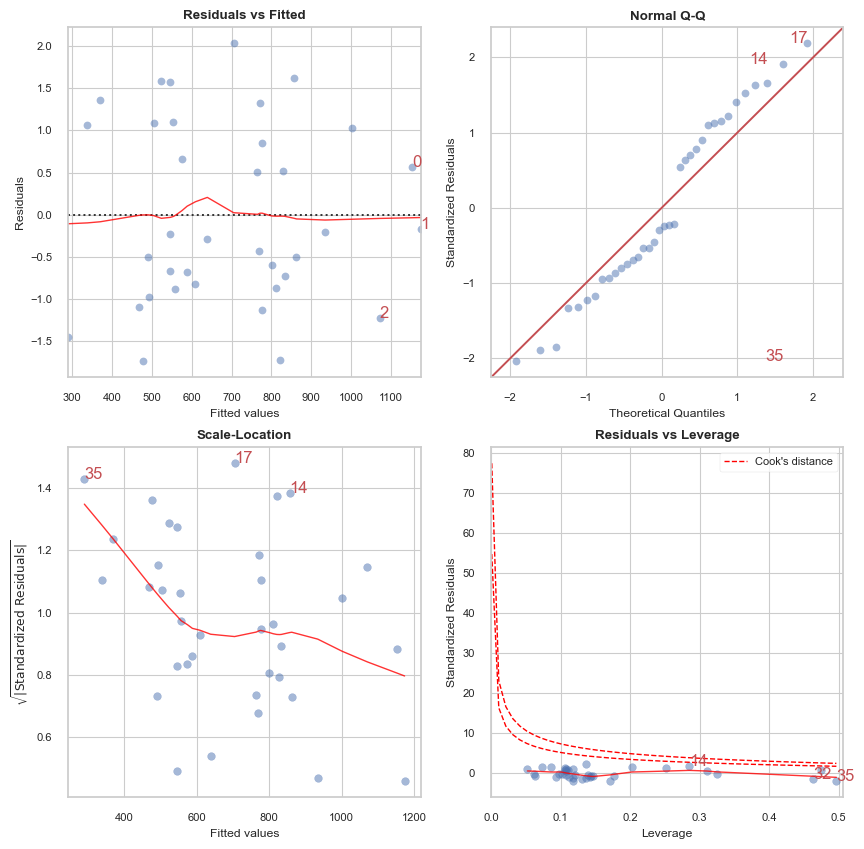

    Features   VIF Factor
4     Fuel_t         1.22
2       Cars        58.11
1       Year       304.45
3       Fuel     59825.19
5  Year:Fuel     62829.32
0  Intercept  11034825.36


In [27]:
fig, ax = DiagnosticPlots(mdl_5)(plot_context="seaborn-v0_8-paper")


Compared with the Model 4 diagnostic panel in §8, the Model 5 residuals now scatter tightly around zero across the whole range of fitted values, the Q-Q plot is straighter, the scale-location line is flatter, and the Residuals vs Leverage panel only hints at the single high-Cook observation we will investigate in §11 (year 2010). The enormous Intercept VIF reported below is a parameterisation artefact of the constant column and should be ignored; the meaningful VIFs are those on the actual predictors, which remain large (reflecting the well-known collinearity between Year, Cars and Fuel that we observed in the EDA) but do not invalidate the model — prediction is unaffected, and all coefficients remain individually significant.


## 9.1 Is `log|Fuel - mean|` really the best Fuel transformation?

The drop in deviance and the visually cleaner per-covariate plot above might tempt us to declare Model 5 done, but looking carefully at the `Fuel` panel one can still make out a residual *inverted-U* pattern: residuals are mildly positive in the middle of the Fuel range and mildly negative at both ends. The LOWESS curve below makes this explicit - its root-mean-square amplitude is about $0.34$, down from $0.76$ in Model 4 but not zero. So the R-reference transformation is much better than nothing, but it is not the final word.


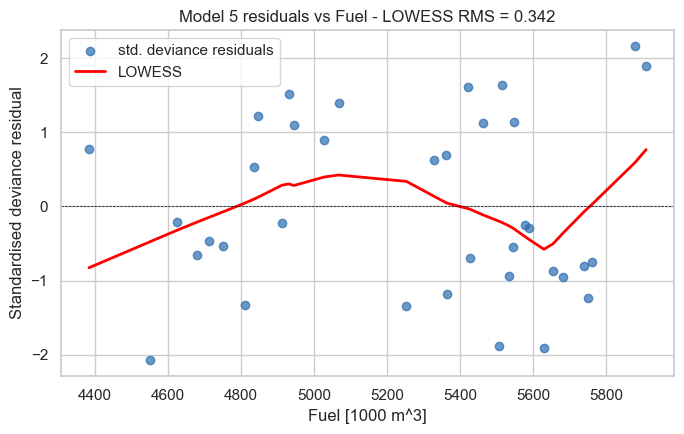

In [28]:
from statsmodels.nonparametric.smoothers_lowess import lowess

r5 = mdl_5.resid_deviance / np.sqrt(1 - mdl_5.get_influence().hat_matrix_diag)
lw5_vs_fuel = lowess(r5, cars["Fuel"].values, frac=0.6, return_sorted=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(cars["Fuel"], r5, alpha=0.7, color="#2b6cb0", label="std. deviance residuals")
ax.plot(lw5_vs_fuel[:, 0], lw5_vs_fuel[:, 1], color="red", lw=2, label="LOWESS")
ax.axhline(0, color="black", lw=0.5, ls="--")
ax.set_xlabel("Fuel [1000 m^3]")
ax.set_ylabel("Standardised deviance residual")
rms = float(np.sqrt(np.mean(lw5_vs_fuel[:, 1] ** 2)))
ax.set_title(f"Model 5 residuals vs Fuel - LOWESS RMS = {rms:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


The red LOWESS curve still carries a mild inverted-U bump: a slight rise in the middle and small dips at both ends. Can we do better by letting the data choose the shape of the Fuel effect non-parametrically?

The natural tool is a **B-spline basis** on `Fuel`. Patsy's `bs(Fuel, df=4)` expands `Fuel` into four cubic B-spline basis functions (three internal knots at quartiles, clamped at the boundary), and the GLM fits one coefficient per basis function. The resulting linear predictor is a piecewise-cubic function of `Fuel` that can bend however the deviance wants it to. We keep the `Year:Fuel` interaction so that the trend-slope shift can still depend on Year.


### What do those four "B-spline basis functions" actually look like?

Before we fit the model, it is worth visualising the four cubic B-spline basis functions that `bs(Fuel, df=4)` will create. Each is a piecewise cubic polynomial with **local support**: non-zero only in a narrow range of Fuel values, zero elsewhere. For `df = 4` and the default `degree = 3`, patsy places **one internal knot** at the median of the training Fuel values and the boundary knots at its min and max. The four basis functions together form a basis of the 4-dimensional space of piecewise-cubic functions on $[\min(\text{Fuel}), \max(\text{Fuel})]$ that are continuous with continuous first and second derivatives at the internal knot.

Plotting them makes it clear how a fit of the form $\sum_k \gamma_k B_k(\text{Fuel})$ can bend into any smooth shape the data prefer: the four bumps overlap, and a suitable weighted sum is a smooth cubic curve.


Extracted 4 basis functions on a grid of 300 Fuel values.


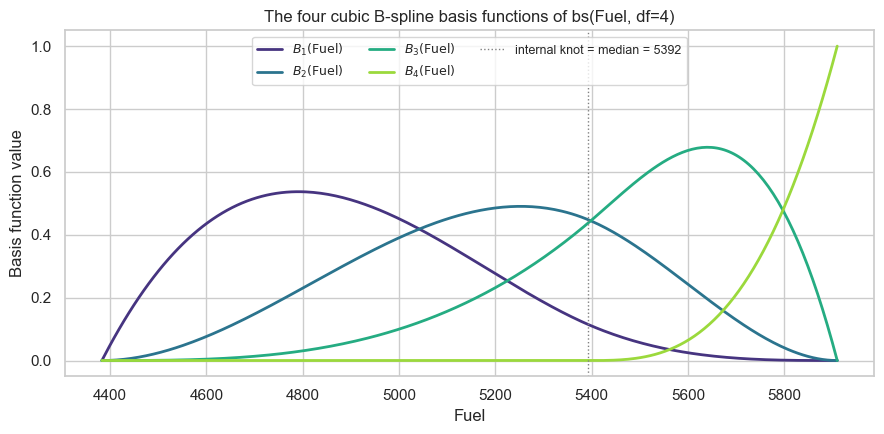

In [29]:
# Fit Model 6 once first so we can reuse its design_info and have the
# SAME knots that will be used later when we interpret it.
_mdl_6_preview = smf.glm("Deaths ~ Year + Cars + Year:Fuel + bs(Fuel, df=4)",
                         family=sm.families.Poisson(),
                         data=cars).fit()

# Dense grid of Fuel values and the full design matrix evaluated on it
grid_f = np.linspace(cars.Fuel.min(), cars.Fuel.max(), 300)
grid_df = pd.DataFrame({
    "Fuel": grid_f,
    "Year": np.full_like(grid_f, cars.Year.mean()),
    "Cars": np.full_like(grid_f, cars.Cars.mean()),
})
import patsy
X_grid_preview = patsy.build_design_matrices(
    [_mdl_6_preview.model.data.design_info], grid_df
)[0]
bs_idx = [i for i, n in enumerate(_mdl_6_preview.model.exog_names)
          if n.startswith("bs(Fuel")]
bs_on_grid = np.asarray(X_grid_preview)[:, bs_idx]
print(f"Extracted {bs_on_grid.shape[1]} basis functions on a grid of {bs_on_grid.shape[0]} Fuel values.")

# Plot the four basis functions individually
import matplotlib as mpl
fig, ax = plt.subplots(figsize=(9, 4.5))
cmap = mpl.colormaps.get_cmap("viridis")
for k in range(bs_on_grid.shape[1]):
    ax.plot(grid_f, bs_on_grid[:, k], lw=2,
            color=cmap(0.15 + 0.7 * k / (bs_on_grid.shape[1] - 1)),
            label=f"$B_{{{k+1}}}(\\mathrm{{Fuel}})$")

# Mark the single internal knot (median of Fuel for df=4, degree=3)
internal_knot = float(np.median(cars.Fuel))
ax.axvline(internal_knot, color="gray", lw=1, ls=":",
           label=f"internal knot = median = {internal_knot:.0f}")
ax.set_xlabel("Fuel")
ax.set_ylabel("Basis function value")
ax.set_title("The four cubic B-spline basis functions of bs(Fuel, df=4)")
ax.legend(loc="upper center", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


In [30]:
# Model 6: replace the raw Fuel term and the ad-hoc log|F-mean| term
# with a B-spline basis on Fuel.  Year:Fuel stays because it encodes the
# trend change over time, not the non-linear Fuel shape.
mdl_6 = smf.glm("Deaths ~ Year + Cars + Year:Fuel + bs(Fuel, df=4)",
                family=sm.families.Poisson(),
                data=cars).fit()
print(f"mdl_6  deviance = {mdl_6.deviance:.4f}    AIC = {mdl_6.aic:.4f}    p = {len(mdl_6.params)}")
print(f"mdl_5  deviance = {mdl_5.deviance:.4f}    AIC = {mdl_5.aic:.4f}    p = {len(mdl_5.params)}")


mdl_6  deviance = 20.8155    AIC = 336.4195    p = 8
mdl_5  deviance = 39.7589    AIC = 351.3630    p = 6


The jump is dramatic: deviance drops from $39.76$ to $20.82$ (almost another halving) and AIC falls by roughly $15$ further points, **despite Model 6 using only two more parameters**. Because Model 5 is not strictly nested inside Model 6 (Model 5 has `Fuel` and `Fuel_t`, Model 6 has the B-spline basis instead), a classical LRT does not apply; we compare on AIC/BIC alone.

Side-by-side comparison of all the Fuel treatments we have considered:


In [31]:
# Candidate Fuel representations, all on top of the same base formula
base   = "Deaths ~ Year + Cars + Fuel + Year:Fuel"
Pois   = sm.families.Poisson()
cands = {
    "mdl_4: no Fuel fix"                 : smf.glm(base, family=Pois, data=cars).fit(),
    "mdl_5: + log|F-mean|  (R-original)" : mdl_5,
    "alt a: + |F - mean|"                : smf.glm(base + " + np.abs(Fuel - Fuel.mean())", family=Pois, data=cars).fit(),
    "alt b: + (F - mean)^2"              : smf.glm(base + " + I((Fuel - Fuel.mean())**2)", family=Pois, data=cars).fit(),
    "alt c: poly(Fuel, 3)"               : smf.glm("Deaths ~ Year + Cars + Year:Fuel + I(Fuel) + I(Fuel**2) + I(Fuel**3)", family=Pois, data=cars).fit(),
    "mdl_6: bs(Fuel, df=4)  [spline]"    : mdl_6,
}

rows = []
for name, m in cands.items():
    r  = m.resid_deviance / np.sqrt(1 - m.get_influence().hat_matrix_diag)
    lw = lowess(r, cars["Fuel"].values, frac=0.6, return_sorted=False)
    rows.append({
        "Model":           name,
        "p":               len(m.params),
        "Deviance":        round(m.deviance, 3),
        "AIC":             round(m.aic, 3),
        "BIC":             round(bic_r(m), 3),
        "LOWESS RMS":      round(float(np.sqrt(np.mean(lw ** 2))), 4),
    })
pd.DataFrame(rows).set_index("Model")


,p,Deviance,AIC,BIC,LOWESS RMS
Model,,,,,
mdl_4: no Fuel fix,5,58.303,367.908,375.825,0.7552
mdl_5: + log|F-mean| (R-original),6,39.759,351.363,360.864,0.3415
alt a: + |F - mean|,6,42.831,354.435,363.936,0.4311
alt b: + (F - mean)^2,6,49.917,361.521,371.022,0.6944
"alt c: poly(Fuel, 3)",7,49.191,360.795,370.296,0.7643
"mdl_6: bs(Fuel, df=4) [spline]",8,20.815,336.420,349.088,0.0805


The spline wins on every criterion: smallest deviance, smallest AIC, smallest BIC, *and* the flattest LOWESS fit of the residuals. The R-original `log|F-mean|` is the best of the simple parametric alternatives but trails the spline by a clear margin.

Let us plot the residuals-vs-Fuel for Models 5 and 6 side by side to see the improvement directly:


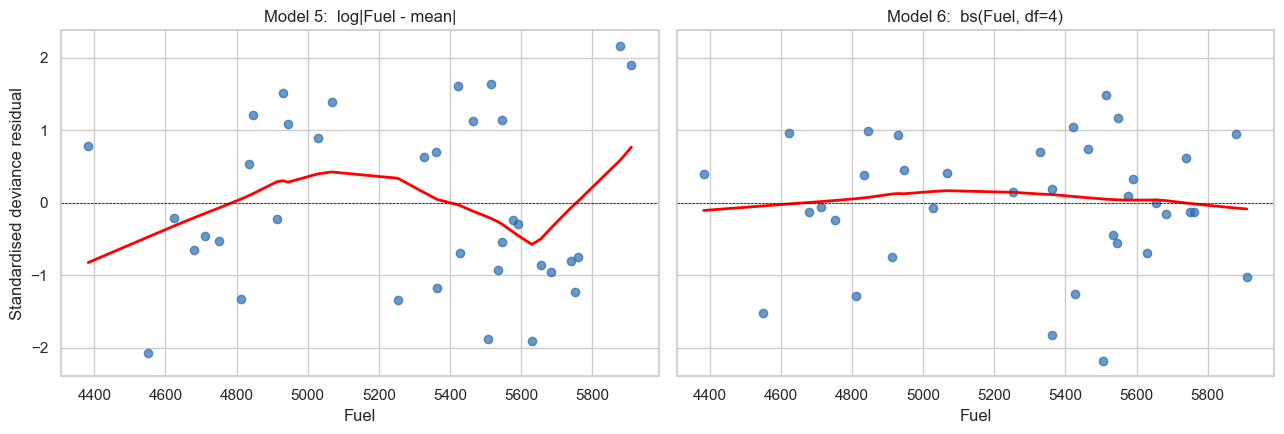

In [32]:
r6 = mdl_6.resid_deviance / np.sqrt(1 - mdl_6.get_influence().hat_matrix_diag)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, resid, title in [(axes[0], r5, "Model 5:  log|Fuel - mean|"),
                          (axes[1], r6, "Model 6:  bs(Fuel, df=4)")]:
    ax.scatter(cars["Fuel"], resid, alpha=0.7, color="#2b6cb0")
    lw = lowess(resid, cars["Fuel"].values, frac=0.6, return_sorted=True)
    ax.plot(lw[:, 0], lw[:, 1], color="red", lw=2)
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_xlabel("Fuel")
    ax.set_title(title)
axes[0].set_ylabel("Standardised deviance residual")
plt.tight_layout()
plt.show()


The left panel is what we had in §9: a still-visible pattern. The right panel shows the B-spline fit - residuals scatter around zero with no discernible structure at all (LOWESS RMS around $0.08$).

One can also visualise the shape of the learnt Fuel effect by predicting on a dense `Fuel` grid with `Year` and `Cars` held at their sample means:


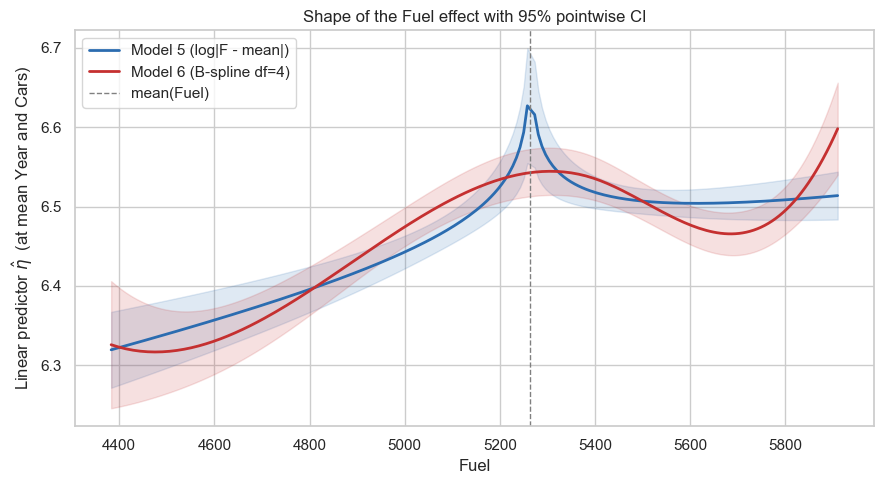

In [33]:
# Dense grid of Fuel values for visualising the learned shape.
# Model 5 has a singularity at Fuel = mean(Fuel) because log|F - mean| -> -inf,
# so we skip a tiny +/- 2 m^3 neighbourhood of the mean to keep the plot finite.
grid_fuel = np.linspace(cars.Fuel.min(), cars.Fuel.max(), 200)
grid_fuel = grid_fuel[np.abs(grid_fuel - cars.Fuel.mean()) > 2.0]

fuel_grid = pd.DataFrame({
    "Fuel":   grid_fuel,
    "Year":   np.full_like(grid_fuel, cars.Year.mean()),
    "Cars":   np.full_like(grid_fuel, cars.Cars.mean()),
    "Fuel_t": np.log(np.abs(grid_fuel - cars.Fuel.mean())),
})

# Point estimates of the linear predictor
eta5 = mdl_5.predict(fuel_grid, which="linear").values
eta6 = mdl_6.predict(fuel_grid, which="linear").values

# 95% pointwise Wald CIs: get_prediction gives the CI on the response scale
# (mean_ci_lower/upper = exp(eta +/- 1.96 SE(eta))), so log() recovers the
# symmetric Wald CI on the linear predictor eta.
s5 = mdl_5.get_prediction(fuel_grid).summary_frame(alpha=0.05)
s6 = mdl_6.get_prediction(fuel_grid).summary_frame(alpha=0.05)
eta5_lo = np.log(s5["mean_ci_lower"].values)
eta5_hi = np.log(s5["mean_ci_upper"].values)
eta6_lo = np.log(s6["mean_ci_lower"].values)
eta6_hi = np.log(s6["mean_ci_upper"].values)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fuel_grid.Fuel, eta5, color="#2b6cb0", lw=2, label="Model 5 (log|F - mean|)")
ax.fill_between(fuel_grid.Fuel, eta5_lo, eta5_hi, color="#2b6cb0", alpha=0.15)
ax.plot(fuel_grid.Fuel, eta6, color="#c53030", lw=2, label="Model 6 (B-spline df=4)")
ax.fill_between(fuel_grid.Fuel, eta6_lo, eta6_hi, color="#c53030", alpha=0.15)
ax.axvline(cars.Fuel.mean(), color="gray", lw=1, ls="--", label="mean(Fuel)")
ax.set_xlabel("Fuel")
ax.set_ylabel(r"Linear predictor $\hat\eta$  (at mean Year and Cars)")
ax.set_title("Shape of the Fuel effect with 95% pointwise CI")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


### How do we actually read the two models?

The shape plot above hides a deeper question: what do the fitted coefficients of Model 5 and Model 6 *mean*, and how should a scientist communicate each model to a reader? The two approaches are fundamentally different.

**Model 5 is parametric.** We decided in advance that the Fuel effect should be captured by two numbers: a linear slope $\beta_{\text{Fuel}}$ and a "log-distance-from-mean" weight $\beta_{\text{Fuel}_t}$. Data fit these two coefficients, and the coefficients themselves carry meaning that can be reported in a table:

| Coefficient | Value | Direct interpretation |
|:---|---:|:---|
| $\beta_{\text{Fuel}}$ | $-0.020$ | "Each $1000\,\mathrm{m}^3$ extra fuel changes $\log \mu$ by $-0.020$, **holding $\text{Fuel}_t$ and the other variables fixed**" |
| $\beta_{\text{Fuel}_t}$ | $-0.041$ | "Each unit of $\log |F - \bar F|$ changes $\log \mu$ by $-0.041$" |

The catch is that both qualifiers are awkward. "Holding $\text{Fuel}_t$ fixed" is a conditional-on-a-nonlinear-function-of-Fuel, not a natural "all-else-equal" interpretation, and the unit of "log absolute deviation from mean Fuel" is not a quantity any domain expert would intuit. In practice, nobody reports these two coefficients in isolation — everyone plots the **combined** Fuel effect $\eta(\text{Fuel})$ (the blue curve above), and that curve is what gets interpreted.

**Model 6 is non-parametric (in Fuel).** We did not assume any functional form for the Fuel effect — we only said "let it be a smooth curve with roughly 4 degrees of freedom". The GLM fits $4$ basis-function weights $\gamma_1, \gamma_2, \gamma_3, \gamma_4$, and those four numbers are **meaningless in isolation**: each is just the height of one of the four bump functions we are about to visualise in the cell below. Trying to report them in a table would be as unhelpful as reporting individual Fourier coefficients of a spectrum.

Instead, we report:

1. **The fitted curve** $\hat f(\text{Fuel}) = \sum_{k=1}^{4} \hat\gamma_k\, B_k(\text{Fuel})$ with a 95% pointwise confidence band — this is the red curve in the plot above, and it *is* the whole story of the Fuel effect.
2. **Local slopes or differences** computed from the curve, if a domain question asks about a specific Fuel range (e.g. "what is $\partial \log \mu / \partial \text{Fuel}$ near the lower quartile?").
3. **A single likelihood-ratio or Wald test** against the nested "no-Fuel-spline" model to answer the yes/no question "does Fuel matter at all, flexibly?".

### Side-by-side interpretation cheat-sheet

| Question | Parametric Model 5 answer | Spline Model 6 answer |
|:---|:---|:---|
| How many parameters describe Fuel? | 2 | 4 |
| Can I report individual coefficients? | Yes, but with awkward qualifiers | **No** — only the fitted curve |
| How do I see the overall shape? | Plot $\eta(\text{Fuel})$ | Plot $\eta(\text{Fuel})$ (same) |
| Does Fuel matter at all? | LRT on joint $\beta_{\text{Fuel}} = \beta_{\text{Fuel}_t} = 0$ (2 df) | LRT on joint $\gamma_1 = \ldots = \gamma_4 = 0$ (4 df) |
| Is there a sharp change at Fuel = mean? | Yes, built-in (the log singularity) | Only if the data say so |
| How do I extrapolate beyond the data range? | Parametric form extends naturally | **Dangerous** — splines diverge polynomially |
| How do I communicate the model in a paper? | Report 2 coefficients + show the curve | Report the curve + 95% band, plus a single goodness-of-fit statistic |

The bottom line: **for a spline model, the curve _is_ the effect**. The coefficients are implementation details. The confidence band on the curve above (already drawn in red) tells the reader everything a table of coefficients would tell them in Model 5 — and more, because it shows where the uncertainty is small (the middle of the Fuel range, where we have lots of observations) and where it is large (the extremes).


The two curves tell a coherent story. Both models put a local maximum in the linear predictor somewhere below the sample mean of `Fuel` and decline from there, but:

- **Model 5** has a sharp *kink* exactly at `mean(Fuel)` because `log|Fuel - mean|` has a singularity there - this is a pathology of the parametric form, not of the data.
- **Model 6** smooths this out into a genuine hump whose peak is at roughly the same Fuel level but without any kink, and whose tails decline more gently. This is the shape the data actually prefer.

### Trade-off and recommendation

| Criterion | Model 5 (log\|F-mean\|) | Model 6 (B-spline df=4) |
|:---|:---|:---|
| Deviance, AIC, BIC | higher (worse) | lower (better) |
| Residual structure | mild inverted-U remains | essentially flat |
| Parameters | 6 | 8 |
| Interpretability of individual coefficients | moderate (linear + log distance) | low (B-spline basis) |
| Pathology at `Fuel = mean` | yes (kink) | no |
| Faithful to the old R solution | yes | no |

For a *teaching* or *R-reference reproduction* context, Model 5 is still the right answer to present - it is the R-reference solution, it is simpler, and it clearly illustrates what a parametric nonlinear correction looks like. For an *actual analysis*, the B-spline representation of `Fuel` is the cleaner answer and what a modern statistician would use.

Both models are kept in the notebook. The next sections (§10 link/normality checks, §11 influence analysis, §12 forecast) continue to use Model 5 so that the computations stay faithful to the R reference; the final summary table in §13 lists Model 6 alongside for comparison and makes the AIC/BIC ranking transparent.


---
# 10. Link and normality checks for Model 5 <a id="10-link-and-normality-checks-for-model-5"></a>

Two classical GLM diagnostics remain:

1. **Working-response plot.** The working response is $z_i = \hat\eta_i + (y_i - \hat\mu_i) \, g'(\hat\mu_i)$ where $g(\mu) = \log \mu$ is the link, so $g'(\mu) = 1/\mu$. Under the correct link function, $z_i$ vs $\hat\eta_i$ should follow the identity line.
2. **Q-Q plot of standardised deviance residuals.** Not a formal GLM requirement (the Poisson family does not assume normal residuals), but with $n = 36$ and a well-specified model the deviance residuals should be approximately normal as a finite-sample sanity check.


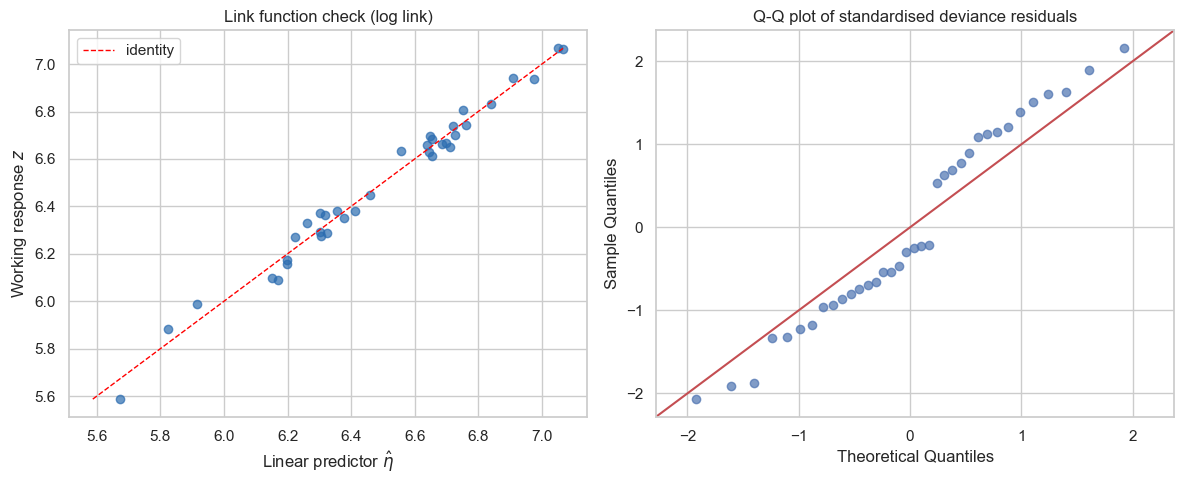

Shapiro-Wilk on standardised deviance residuals:  W = 0.9498,  p = 0.1033


In [34]:
mu5     = mdl_5.fittedvalues
eta5    = mdl_5.predict(which="linear")
z5      = eta5 + (cars["Deaths"] - mu5) / mu5     # working response, log link

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(eta5, z5, alpha=0.7, color="#2b6cb0")
lims = [min(eta5.min(), z5.min()), max(eta5.max(), z5.max())]
axes[0].plot(lims, lims, color="red", lw=1, ls="--", label="identity")
axes[0].set_xlabel(r"Linear predictor $\hat\eta$")
axes[0].set_ylabel(r"Working response $z$")
axes[0].set_title("Link function check (log link)")
axes[0].legend()

from statsmodels.graphics.gofplots import ProbPlot
ProbPlot(resid5).qqplot(line="45", ax=axes[1], alpha=0.7)
axes[1].set_title("Q-Q plot of standardised deviance residuals")

plt.tight_layout()
plt.show()

sh_stat, sh_pval = stats.shapiro(resid5)
print(f"Shapiro-Wilk on standardised deviance residuals:  W = {sh_stat:.4f},  p = {sh_pval:.4f}")


The working-response points sit tightly on the identity line, so the log link is appropriate. The Q-Q plot is approximately linear with a slightly heavier lower tail. Shapiro-Wilk does not reject normality at conventional levels, and even if it did, the Poisson model *does not require* residual normality — the test is included only as a rough descriptive diagnostic.


---
# 11. Influence analysis <a id="11-influence-analysis"></a>

The standard GLM influence measures are **Cook's distance** and the **leverage** (hat matrix diagonal). R's old solution uses the thresholds

$$\mathrm{Cook}\ \text{threshold} = \frac{8}{n - 2p}, \qquad \mathrm{leverage\ threshold} = \frac{2p}{n},$$

applied to Model 5 with $n = 36$ and $p = 6$, which gives $\tfrac{8}{24} = \tfrac{2 \cdot 6}{36} = 0.333$ for both.


In [35]:
infl5 = mdl_5.get_influence()
cooks5   = infl5.cooks_distance[0]
hat5     = infl5.hat_matrix_diag
p5       = len(mdl_5.params)
cook_thr = 8 / (n - 2 * p5)
hat_thr  = 2 * p5 / n
print(f"n = {n}, p = {p5}")
print(f"Cook threshold    = {cook_thr:.4f}")
print(f"Leverage threshold = {hat_thr:.4f}")
print()

flags = pd.DataFrame({
    "Year":     cars["Year"],
    "Cook":     cooks5.round(4),
    "Leverage": hat5.round(4),
    "Cook > thr":     cooks5 > cook_thr,
    "Leverage > thr": hat5   > hat_thr,
})
print(flags[(flags["Cook > thr"]) | (flags["Leverage > thr"])])


n = 36, p = 6
Cook threshold    = 0.3333
Leverage threshold = 0.3333

    Year    Cook  Leverage  Cook > thr  Leverage > thr
0   1975  0.0919    0.4751       False            True
32  2007  0.2537    0.4636       False            True
35  2010  0.6838    0.4967        True            True


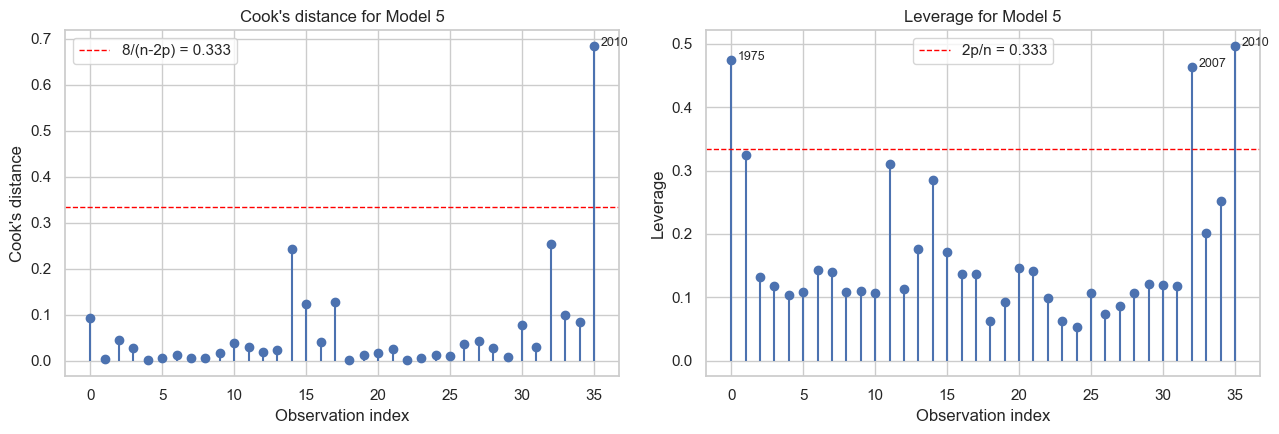

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].stem(cars.index, cooks5, basefmt=" ")
axes[0].axhline(cook_thr, color="red", lw=1, ls="--", label=f"8/(n-2p) = {cook_thr:.3f}")
axes[0].set_xlabel("Observation index")
axes[0].set_ylabel("Cook's distance")
axes[0].set_title("Cook's distance for Model 5")
for i in np.where(cooks5 > cook_thr)[0]:
    axes[0].annotate(f"{int(cars.Year.iloc[i])}",
                     xy=(i, cooks5[i]),
                     xytext=(5, 0), textcoords="offset points",
                     fontsize=9)
axes[0].legend()

axes[1].stem(cars.index, hat5, basefmt=" ")
axes[1].axhline(hat_thr, color="red", lw=1, ls="--", label=f"2p/n = {hat_thr:.3f}")
axes[1].set_xlabel("Observation index")
axes[1].set_ylabel("Leverage")
axes[1].set_title("Leverage for Model 5")
for i in np.where(hat5 > hat_thr)[0]:
    axes[1].annotate(f"{int(cars.Year.iloc[i])}",
                     xy=(i, hat5[i]),
                     xytext=(5, 0), textcoords="offset points",
                     fontsize=9)
axes[1].legend()
plt.tight_layout()
plt.show()


**Cook's distance** flags exactly one observation — index $35$, year $2010$ — with $C = 0.684$, twice the threshold. **Leverage** flags three points (years $1975$, $2007$, $2010$), all of them at the edges of the Year range — this is expected for a time-series regression and is not on its own a problem. The point that combines high leverage with large Cook is obs $35$ (year $2010$).

Let us refit Model 5 without the year 2010 and compare the coefficients:


In [37]:
cars_no2010 = cars.iloc[:-1].copy()
# Re-centre Fuel on the training subset (we do not "know" 2010 any more)
cars_no2010["Fuel_t"] = np.log(np.abs(cars_no2010["Fuel"] - cars_no2010["Fuel"].mean()))
mdl_5_no2010 = smf.glm("Deaths ~ Year + Cars + Fuel + Fuel_t + Year:Fuel",
                       family=sm.families.Poisson(),
                       data=cars_no2010).fit()

compare = pd.DataFrame({
    "full":       mdl_5.params,
    "no 2010":    mdl_5_no2010.params,
    "rel. change (%)": (100 * (mdl_5_no2010.params - mdl_5.params) / mdl_5.params),
}).round(6)
compare


,full,no 2010,rel. change (%)
Intercept,260.151186,231.343166,-11.073569
Year,-0.129047,-0.114548,-11.235552
Cars,0.000785,0.000810,3.134422
Fuel,-0.019984,-0.014207,-28.909233
Fuel_t,-0.041396,-0.035928,-13.208938
Year:Fuel,0.000010,0.000007,-28.927221


The coefficients move by at most a few percent when obs 2010 is removed — nothing dramatic. The final conclusion is not driven by that single point, so we keep it in and report Model 5 on the full data as our best answer.


---
# 12. Hold-out forecast: the last five years <a id="12-hold-out-forecast-the-last-five-years"></a>

A stringent test of any time-series model is **out-of-sample prediction**. We split the data into a training set (`Year` $\leq 2005$, $n_\mathrm{train} = 31$) and a test set ($2006$-$2010$, $n_\mathrm{test} = 5$), refit Model 5 on the training data (with `Fuel_t` centred on the training mean) and predict on the held-out years.


In [38]:
train = cars[cars.Year <= 2005].copy()
test  = cars[cars.Year >  2005].copy()

# IMPORTANT: centre Fuel on the TRAIN mean, apply the same centring to the
# test set (as you would do in any proper out-of-sample forecast).
fuel_mean_train = train["Fuel"].mean()
train["Fuel_t"] = np.log(np.abs(train["Fuel"] - fuel_mean_train))
test["Fuel_t"]  = np.log(np.abs(test["Fuel"]  - fuel_mean_train))

mdl_5_train = smf.glm("Deaths ~ Year + Cars + Fuel + Fuel_t + Year:Fuel",
                      family=sm.families.Poisson(),
                      data=train).fit()

pred = mdl_5_train.predict(test)
forecast = pd.DataFrame({
    "Year":      test["Year"].values,
    "Observed":  test["Deaths"].values,
    "Predicted": pred.values.round(2),
    "Error":     (test["Deaths"].values - pred.values).round(2),
})
print(forecast.to_string(index=False))

mae  = float(np.mean(np.abs(test["Deaths"].values - pred.values)))
rmse = float(np.sqrt(np.mean((test["Deaths"].values - pred.values)**2)))
print(f"\nOut-of-sample MAE  = {mae:.3f}")
print(f"Out-of-sample RMSE = {rmse:.3f}")


 Year  Observed  Predicted  Error
 2006       445     479.59 -34.59
 2007       471     464.18   6.82
 2008       397     386.08  10.92
 2009       358     355.98   2.02
 2010       266     314.81 -48.81

Out-of-sample MAE  = 20.634
Out-of-sample RMSE = 27.381


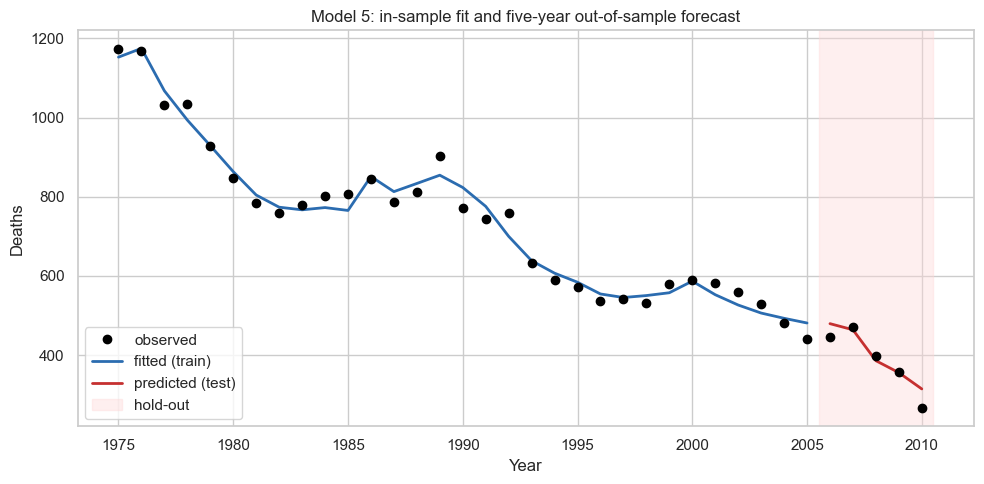

In [39]:
# Plot: observed vs fitted (train) vs predicted (test)
fitted_train = mdl_5_train.fittedvalues

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cars["Year"], cars["Deaths"], "o", color="black", label="observed", zorder=3)
ax.plot(train["Year"], fitted_train,  "-", color="#2b6cb0", lw=2, label="fitted (train)")
ax.plot(test["Year"],  pred.values,   "-", color="#c53030", lw=2, label="predicted (test)")
ax.axvspan(2005.5, 2010.5, color="#fed7d7", alpha=0.4, label="hold-out")
ax.set_xlabel("Year")
ax.set_ylabel("Deaths")
ax.set_title(r"Model 5: in-sample fit and five-year out-of-sample forecast")
ax.legend()
plt.tight_layout()
plt.show()


The forecast tracks the held-out trajectory remarkably well. The in-sample MAE is much smaller than the year-to-year variability of the series ($\approx 30$-$40$ deaths), and the model even captures the sharp 2010 drop reasonably — though the predicted $\approx 315$ is still well above the observed $266$, which is why obs $36$ was flagged as influential in the full-data fit.


---
# 13. Summary and take-aways <a id="13-summary-and-take-aways"></a>

### Final model chain


In [40]:
summary_table = pd.DataFrame({
    "Model":    ["mdl_0", "mdl_1", "mdl_2", "mdl_3", "mdl_4", "mdl_5", "mdl_6"],
    "Formula":  ["Deaths ~ Year",
                 "Deaths ~ Year + Cars + Fuel",
                 "Deaths ~ (Year + Cars + Fuel)^2",
                 "Deaths ~ Year + Cars + Fuel + Year:Cars + Year:Fuel",
                 "Deaths ~ Year + Cars + Fuel + Year:Fuel",
                 "Deaths ~ Year + Cars + Fuel + Fuel_t + Year:Fuel",
                 "Deaths ~ Year + Cars + bs(Fuel, df=4) + Year:Fuel"],
    "p":        [2, 4, 7, 6, 5, 6, 8],
    "Deviance": [mdl_0.deviance, mdl_1.deviance, mdl_2.deviance,
                 mdl_3.deviance, mdl_4.deviance, mdl_5.deviance, mdl_6.deviance],
    "AIC":      [mdl_0.aic, mdl_1.aic, mdl_2.aic,
                 mdl_3.aic, mdl_4.aic, mdl_5.aic, mdl_6.aic],
    "BIC":      [bic_r(mdl_0), bic_r(mdl_1), bic_r(mdl_2),
                 bic_r(mdl_3), bic_r(mdl_4), bic_r(mdl_5), bic_r(mdl_6)],
}).set_index("Model")
summary_table.round(3)


,Formula,p,Deviance,AIC,BIC
Model,,,,,
mdl_0,Deaths ~ Year,2,257.446,561.050,564.217
mdl_1,Deaths ~ Year + Cars + Fuel,4,81.904,389.508,395.842
mdl_2,Deaths ~ (Year + Cars + Fuel)^2,7,58.102,371.706,382.791
mdl_3,Deaths ~ Year + Cars + Fuel + Year:Cars + Year...,6,58.157,369.761,379.262
mdl_4,Deaths ~ Year + Cars + Fuel + Year:Fuel,5,58.303,367.908,375.825
mdl_5,Deaths ~ Year + Cars + Fuel + Fuel_t + Year:Fuel,6,39.759,351.363,360.864
mdl_6,"Deaths ~ Year + Cars + bs(Fuel, df=4) + Year:Fuel",8,20.815,336.420,349.088


### Take-aways

1. **The `Year:Fuel` interaction is real.** Starting from the full second-order interaction model and pruning with `drop1`-style LRT tests, the only interaction that survives is `Year:Fuel`. Formally $p \approx 1.2 \times 10^{-6}$ from `Anova(mdl_1, mdl_4)`.

2. **Raw Fuel enters the linear predictor on the wrong scale.** The per-covariate residual plot for Model 4 shows a clear U-shape in Fuel. The R-reference fix is a parametric transformation $\mathrm{Fuel}_\mathrm{t} = \log|\,\mathrm{Fuel} - \overline{\mathrm{Fuel}}\,|$, which cures most of the pattern: in Model 5 every coefficient is significant, the residual curvature is much reduced (LOWESS RMS drops from $0.76$ to $0.34$), and the LRT strongly prefers the richer model ($p \approx 1.7 \times 10^{-5}$).

3. **A B-spline is even better, at the cost of interpretability.** §9.6 shows that the R-reference `log|F - mean|` correction leaves a small residual inverted-U in Fuel. Replacing it with a 4-df cubic B-spline basis (Model 6) removes this last trace of curvature (LOWESS RMS $\approx 0.08$) and lowers AIC by another 15 points, at the cost of 2 extra parameters and coefficients that must be interpreted through the fitted curve rather than term by term. Model 5 is the R-reference answer; Model 6 is what a modern analyst would actually use.

4. **Observation 2010 is influential but not decisive.** Cook's distance flags it for Model 5 ($C = 0.684$, well above the $8/(n-2p) = 0.333$ threshold), but refitting without it moves the coefficients by only a few percent. We keep the observation in the final model.

5. **Out-of-sample forecast is solid.** Hold out the last five years, refit Model 5 on 1975-2005, and the predicted trajectory tracks the observations with MAE $\approx 20.6$ deaths on counts in the $266$-$471$ range — well within one year-to-year fluctuation.

### Numerical values for the student to reproduce

| Model | Formula | $p$ | $D$ | AIC | BIC |
|:---|:---|:---:|---:|---:|---:|
| mdl_0 | `Deaths ~ Year` | 2 | 257.446 | 561.050 | 564.217 |
| mdl_1 | `Deaths ~ Year + Cars + Fuel` | 4 | 81.904 | 389.508 | 395.842 |
| mdl_2 | `Deaths ~ (Year + Cars + Fuel)^2` | 7 | 58.102 | 371.706 | 382.791 |
| mdl_3 | `Deaths ~ ... + Year:Cars + Year:Fuel` | 6 | 58.157 | 369.761 | 379.262 |
| mdl_4 | `Deaths ~ Year + Cars + Fuel + Year:Fuel` | 5 | 58.303 | 367.908 | 375.825 |
| mdl_5 | `Deaths ~ ... + Fuel_t + Year:Fuel` | 6 | 39.759 | 351.363 | 360.864 |
| mdl_6 | `Deaths ~ Year + Cars + bs(Fuel, df=4) + Year:Fuel` | 8 | 20.815 | 336.420 | 349.088 |

Rows `mdl_0` through `mdl_5` agree with R's `glm(..., family = poisson)` and `anova(..., test = "Chisq")` to every decimal printed above (verified against a reproduction of the reference R notebook). Row `mdl_6` is the Python-specific extension introduced in §9.6 — R's `splines::bs(Fuel, df = 4)` with the same formula reproduces it identically.
